In [1]:
from __future__ import annotations
import pyvisa
import numpy as np
import scipy.interpolate as interpolate
import h5py as h5
import importlib
from Oscilloscope import digitizer_base
importlib.reload(digitizer_base)
from Oscilloscope.digitizer_base import Digitizer
scope_module = importlib.import_module("Oscilloscope.Scope")
importlib.reload(scope_module)
from Oscilloscope.Scope import Scope
import matplotlib.pyplot as plt
import os

In [2]:
import pyvisa
try:
    rm = pyvisa.ResourceManager()
except Exception as exc:
    # Fall back to the pure Python backend if NI-VISA is missing.
    print(f"Default backend failed: {exc}")
    rm = pyvisa.ResourceManager("@py")

print(rm.list_resources())

('TCPIP0::k-mx3024g-00117.local::hislip0::INSTR', 'TCPIP0::k-mx3024g-00117.local::inst0::INSTR')


In [3]:
s = Scope(visa_address='TCPIP0::k-mx3024g-00117.local::hislip0::INSTR')
s.DSO.timeout = 700000  

In [25]:
t, x = s.acquire_segmented(channels=[3], seg=1)


In [7]:
t.shape, x.shape

((3253,), (1, 950, 3253))

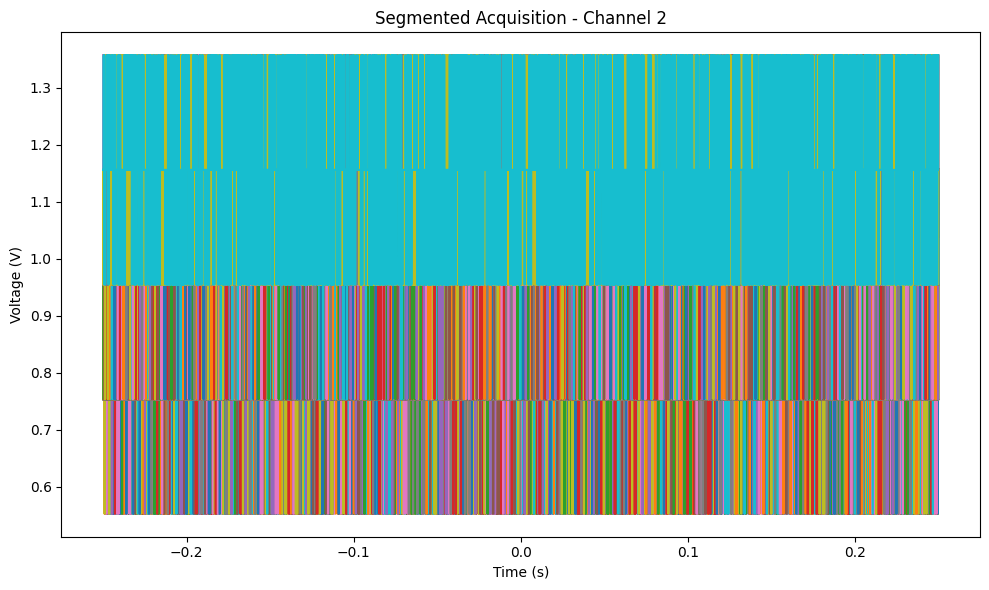

In [ ]:
fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6))
for i in range(100):
    ax1.plot(t, x[0, i], label=f"Segment {i+1}")
ax1.set_title("Segmented Acquisition - Channel 3")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")
plt.tight_layout()

In [26]:
#Put every segment together to become one long signal
dt = t[1] - t[0]
x_long = []
for i in range(len(x[0])):
    x_long.extend(x[0, i])
t_long = np.arange(0, len(x_long)*dt, dt)
#Save long data to csv file
#Check if file exists
if os.path.exists("Data\segmented_acquisition_channel_5_PID.csv"):
    print("File already exists. Not saving.")
else:
    np.savetxt("Data\segmented_acquisition_channel_5_PID.csv", np.column_stack((t_long, x_long)), delimiter=",", header="Time (s), Voltage (V)", comments="")
    

File already exists. Not saving.


Text(0, 0.5, 'Voltage (V)')

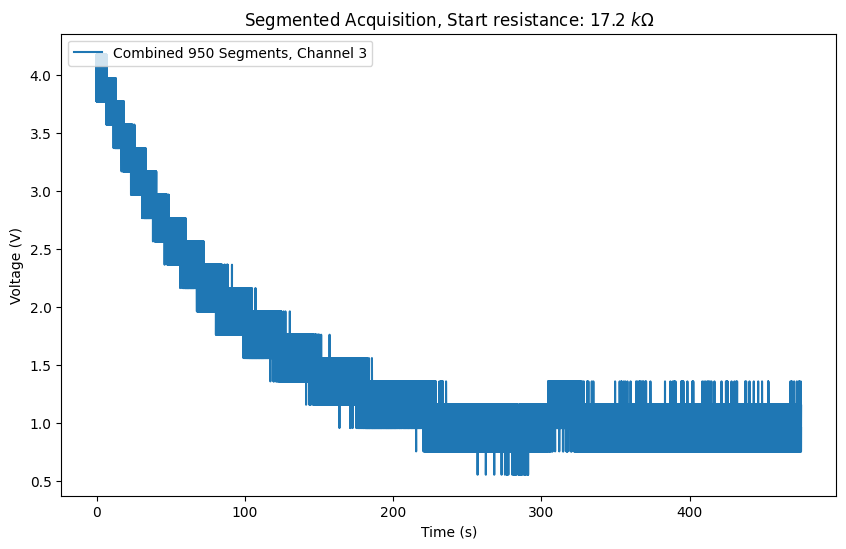

In [9]:

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6))
ax1.plot(t_long, x_long, label=f"Combined {len(x[0])} Segments, Channel 3")
ax1.set_title("Segmented Acquisition, Start resistance: 17.2 $k\Omega$")
ax1.legend(loc="upper left")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")

In [27]:
avg_x_long = np.mean(x_long)
print(f"Average voltage: {np.round(avg_x_long, 2)} V")

Average voltage: 1.09 V


In [24]:
#Convert voltage to Ohm
x_long = np.asarray(x_long)
def voltage_to_kOhm(voltage):
    r = voltage * 20
    return np.asarray(r)
resist = voltage_to_kOhm(x_long)
temperature = np.array([
    -40, -35, -30, -25, -20, -15, -10, -5,
      0,   5,  10,  15,  20,  25,  30,  35,
     40,  45,  50,  55,  60,  65,  70,  75,
     80,  85,  90,  95, 100
])
resistance_nominal = np.array([
    2664.0, 1933.0, 1421.0, 1052.0,  788.5,  594.4,  453.0,  347.6,
     269.3,  209.7,  164.8,  130.1,  103.6,   83.00,  66.91,  54.19,
      44.18,  36.17,  29.80,  24.65,  20.51,  17.13,  14.37,  12.10,
      10.24,   8.700,  7.419,  6.351,  5.460
]) #kOhm
fit = interpolate.interp1d(temperature, resistance_nominal, kind='cubic')
temperature_fit = np.linspace(temperature.min(), temperature.max(), 100)
resistance_fit = fit(temperature_fit)
def temperature_from_resistance(res):
    """
    Calculate the temperature corresponding to a given resistance using the cubic spline fit.
    """
    # Create an inverse function for the fit
    inverse_fit = interpolate.interp1d(resistance_fit, temperature_fit, kind='cubic', fill_value="extrapolate")
    return inverse_fit(res)
temp = temperature_from_resistance(resist)



In [47]:
def voltage_to_kOhm(voltage):
    r = voltage * 20
    return np.asarray(r)
avg_r = voltage_to_kOhm(avg_x_long)
print(f"Average resistance: {np.round(avg_r, 2)} kOhm")

Average resistance: 46.54 kOhm


File already exists. Not saving.


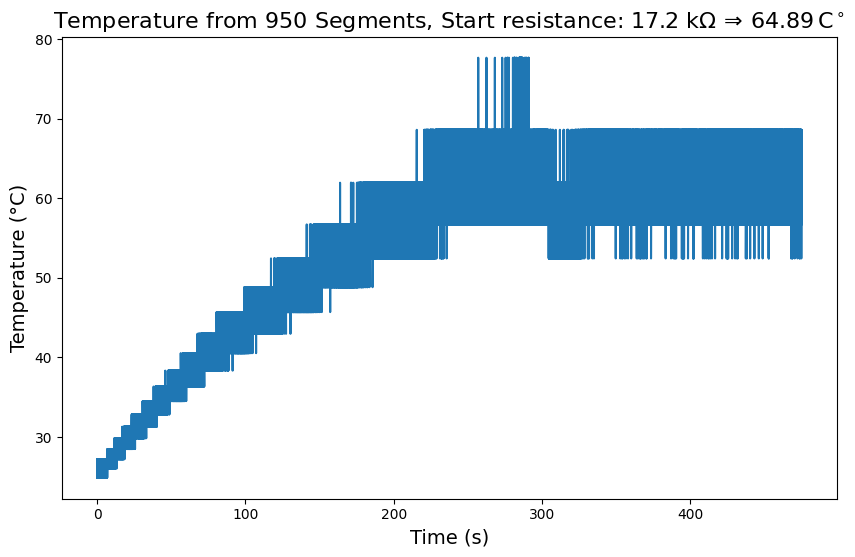

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_long, temp, label=f"Temperature from {len(x[0])} Segments, Channel 2")    
ax.set_title(f"Temperature from {len(x[0])} Segments, Start resistance: 17.2 k$\Omega\,\Rightarrow\, 64.89\, \mathrm{{C}}^\circ$",fontsize=16)
# ax.legend(loc="upper right", fontsize=16)
ax.set_xlabel("Time (s)",fontsize=14)
ax.set_ylabel("Temperature (°C)",fontsize=14)
#Save long data to csv file
#Check if file exists
if os.path.exists("Data\\temperature_calculation_5_PID.csv"):
    print("File already exists. Not saving.")
else:
    np.savetxt("Data\\temperature_calculation_5_PID.csv", np.column_stack((t_long, temp)), delimiter=",", header="Time (s), Temperature (°C)", comments="")
    

In [7]:
#Find the avarage temperature for each segment and save to csv file
average_temperatures = []
for i in range(len(x[0])):
    segment_resist = voltage_to_kOhm(x[0, i])
    segment_temp = temperature_from_resistance(segment_resist)
    average_temperatures.append(np.mean(segment_temp))
#Save average temperatures to csv file
if os.path.exists("Data\\average_temperatures_7_PID.csv"):
    print("File already exists. Not saving.")
else:
    np.savetxt("Data\\average_temperatures_7_PID.csv", average_temperatures, delimiter=",")

File already exists. Not saving.


In [10]:
average_temperatures

[np.float64(58.23876261004254)]

Text(0, 0.5, 'Temperature (°C)')

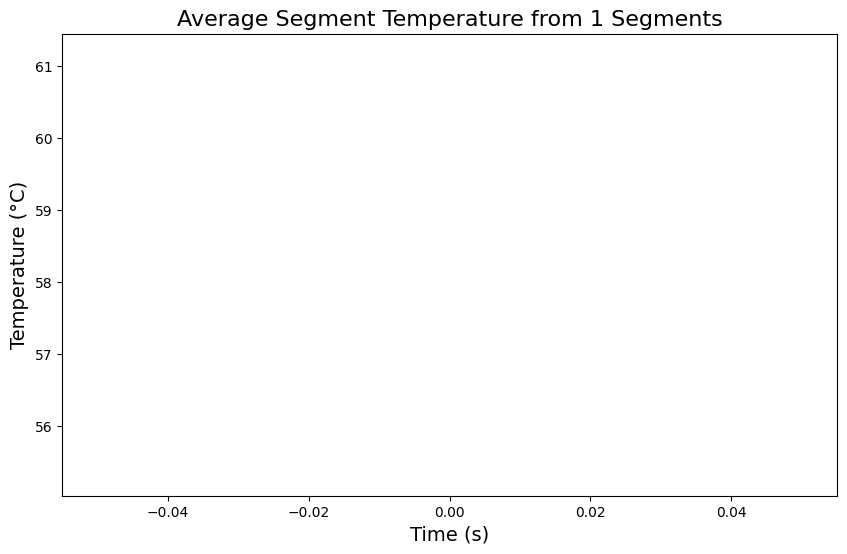

In [9]:
dt = 0.5#s
time = np.linspace(0, len(average_temperatures)*dt, len(average_temperatures))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(time, average_temperatures, label=f"Average Temperature from {len(x[0])} Segments, Channel 2")
ax.set_title(f"Average Segment Temperature from {len(x[0])} Segments", fontsize=16)
ax.set_xlabel("Time (s)", fontsize=14)
ax.set_ylabel("Temperature (°C)", fontsize=14)
# ax.set_xlim(175, 325)


In [ ]:
def _select_channel(x, channel_index):
    if x.ndim == 1:
        return x
    return x[:, channel_index]

def find_frequency(t, x, channel_index=0, min_freq=0.5, max_freq=1000.0):
    '''
    Estimate frequency in Hz using FFT peak within a band.
    '''
    x_ch = _select_channel(x, channel_index)
    if x_ch.size < 2:
        return float("nan")
    dt = float(np.mean(np.diff(t)))
    if dt <= 0:
        return float("nan")
    x_centered = x_ch - np.mean(x_ch)
    # Window to reduce spectral leakage.
    window = np.hanning(x_centered.size)
    spectrum = np.fft.rfft(x_centered * window)
    freqs = np.fft.rfftfreq(x_centered.size, d=dt)
    # Focus on plausible range to avoid noise spikes.
    mask = (freqs >= min_freq) & (freqs <= max_freq)
    if not np.any(mask):
        return float("nan")
    idx = np.argmax(np.abs(spectrum[mask]))
    return float(freqs[mask][idx])

def find_amplitude(x, channel_index=0):
    # Peak-to-peak amplitude (Delta Y).
    x_ch = _select_channel(x, channel_index)
    return np.max(x_ch) - np.min(x_ch)


In [ ]:
channel_index = 1  # Channel 2 (0-based index)
frequency = find_frequency(t, x, channel_index=channel_index, min_freq=0.001, max_freq=1)
amplitude = find_amplitude(x, channel_index=channel_index)
print(f"Frequency: {frequency:.2f} Hz")
print(f"Amplitude: {amplitude:.4f} V")

Frequency: nan Hz
Amplitude: 0.0055 V


| Set Frequency [Hz] | Recorded Frequency [Hz] |  Set Amplitude [V] | Recorded Amplitude [V] | 
| ----------- | ----------- | ----------- | ----------- |
|  20  |  20  |  4  |  4.1005  |
|  10  |  10  |  3  |  3.0955  |
|  2  |  2  |  2  |  2.0905  |
|  0.1  |  0.1  |  2  |  2.0704  |

In [52]:
r_actual = np.array([50,45,40,35,30,25])
r_record = np.array([46.54,41.62, 36.64, 31.55,26.74,21.96])
diff = r_actual - r_record
print("Actual resistances (kOhm):", r_actual)
print("Recorded resistances (kOhm):", r_record)
print("Difference (kOhm):", diff)
temp_actual = temperature_from_resistance(r_actual)
temp_record = temperature_from_resistance(r_record)
diff_temp = temp_actual - temp_record
print("Actual temperatures (°C):", temp_actual)
print("Recorded temperatures (°C):", temp_record)
print("Difference in temperatures (°C):", np.round(diff_temp, decimals=2))

Actual resistances (kOhm): [50 45 40 35 30 25]
Recorded resistances (kOhm): [46.54 41.62 36.64 31.55 26.74 21.96]
Difference (kOhm): [3.46 3.38 3.36 3.45 3.26 3.04]
Actual temperatures (°C): [36.95217296 39.54469379 42.46950312 45.83708745 49.82525749 54.62360133]
Recorded temperatures (°C): [38.71335505 41.48077263 44.67290244 48.51278975 52.84064029 58.1255653 ]
Difference in temperatures (°C): [-1.76 -1.94 -2.2  -2.68 -3.02 -3.5 ]


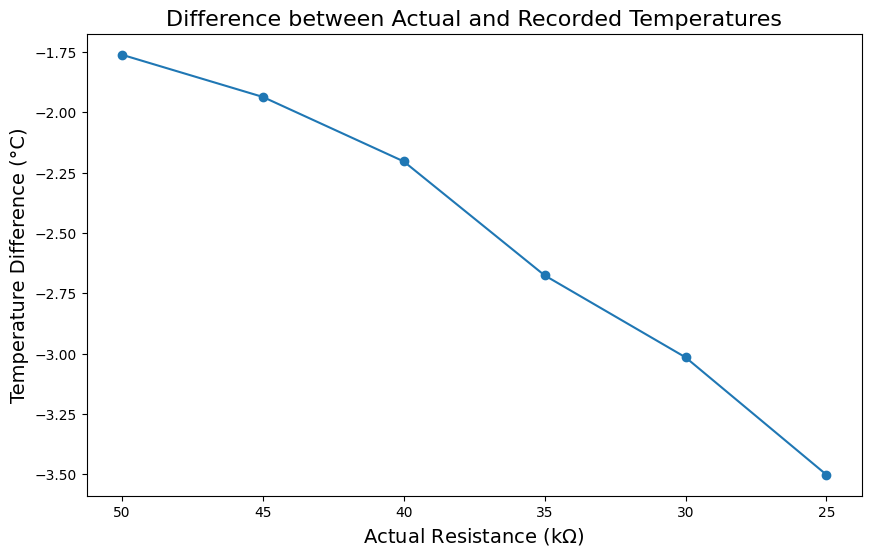

In [ ]:
#Plot x axis in reverse order to show the actual resistance decreasing
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(r_actual, diff_temp, label="Actual", marker='o')
ax.set_title("Difference between Actual and Recorded Temperatures", fontsize=16)
ax.set_xlabel("Actual Resistance (k$\Omega$)", fontsize=14)
ax.set_ylabel("Temperature Difference (°C)", fontsize=14)
#Reverse x axis
ax.invert_xaxis()

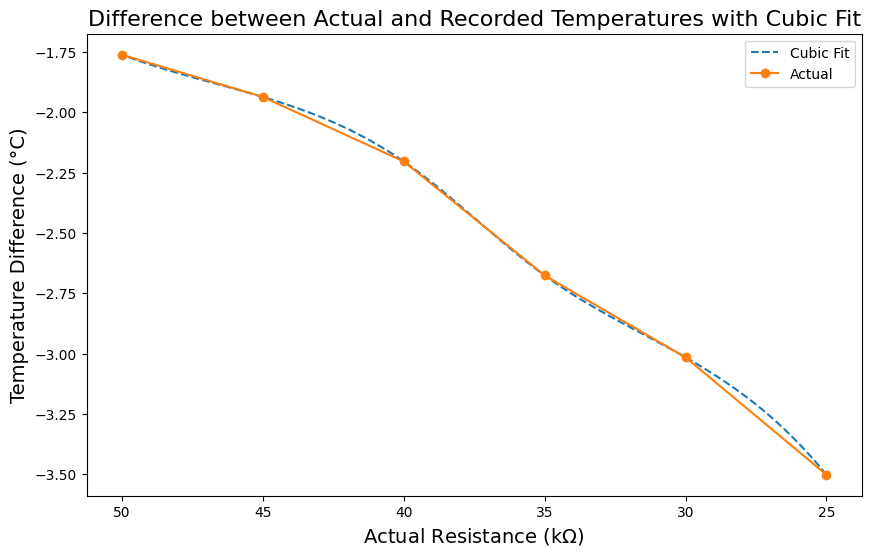

In [62]:
fit = interpolate.interp1d(r_actual, diff_temp, kind='cubic')
resistance_fit = np.linspace(r_actual.min(), r_actual.max(), 100)
diff_temp_fit = fit(resistance_fit)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(resistance_fit, diff_temp_fit, label="Cubic Fit", linestyle='--')
ax.plot(r_actual, diff_temp, label="Actual", marker='o')
ax.set_title("Difference between Actual and Recorded Temperatures with Cubic Fit", fontsize=16)
ax.set_xlabel("Actual Resistance (k$\Omega$)", fontsize=14)
ax.set_ylabel("Temperature Difference (°C)", fontsize=14)
ax.invert_xaxis()
ax.legend()

Slope of the fit: 0.0489 V/kΩ
20.47


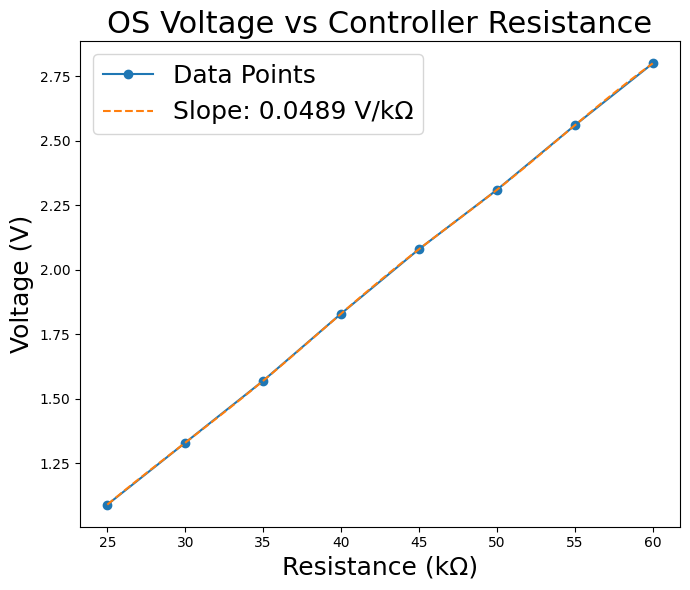

In [45]:
x = np.array([60, 55, 50, 45, 40, 35, 30, 25])
y = np.array([2.8, 2.56, 2.31, 2.08, 1.83, 1.57, 1.33, 1.09])
fig, ax = plt.subplots(figsize=(7, 6), tight_layout=True)
ax.plot(x, y, label="Data Points", marker='o')
ax.set_title("OS Voltage vs Controller Resistance", fontsize=22)
ax.set_xlabel("Resistance (kΩ)", fontsize=18)
ax.set_ylabel("Voltage (V)", fontsize=18)
fit = interpolate.interp1d(x, y, kind='cubic')
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = fit(x_fit)
slope = (y_fit[-1] - y_fit[0]) / (x_fit[-1] - x_fit[0])
ax.plot(x_fit, y_fit, label=f"Slope: {slope:.4f} V/kΩ", linestyle='--')
print(f"Slope of the fit: {slope:.4f} V/kΩ")
ax.legend(fontsize=18)
print(np.round(1/slope, decimals=2))